## ZNE Workflow Implementation
This workflow provides comparision of ZNE with different noise levels 3 points (1,3,5) and 5 points(1,3,5,7,9). It uses global folding feature to show the improvements in error mitigation over a noisy backend for a 4 qubit GHZ circuit with XXXX observable where the ideal value of the observable is 1.0. The ZNE workflow demonstrates how the mitigated expectation value approaches the ideal value as we increase the noise factors and use extrapolation techniques.

### Imports 

In [15]:
from __future__ import annotations

import warnings
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import (
    StatevectorEstimator,
    BackendEstimatorV2,
)

from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error,
    pauli_error,
)
from zne_estimator import ZNEEstimator

# Reproducibility.
np.random.seed(42)
warnings.filterwarnings("ignore", category=DeprecationWarning)

print("Setup complete.")

Setup complete.


### GHZ Circuit

In [16]:
def build_ghz(n_qubits: int) -> QuantumCircuit:
    """Standard GHZ preparation: H on qubit 0, then a chain of CNOTs."""
    qc = QuantumCircuit(n_qubits, name=f"GHZ({n_qubits})")
    qc.h(0)
    for i in range(n_qubits - 1):
        qc.cx(i, i + 1)
    return qc


N_QUBITS = 4
ghz = build_ghz(N_QUBITS)

# Non-trivial observable: the GHZ parity Z⊗Z⊗...⊗Z.
# Ideal expectation value on |GHZ⟩ is +1 because |0…0⟩ and |1…1⟩ both
# have parity +1 under Z^⊗n (for any n; even n gives both eigenvalues +1,
# odd n gives +1 and -1 which sum/2 to 0 — so we pick even n or use XX...X).
# To keep it non-trivial for any n, we use the GHZ stabiliser X⊗X⊗...⊗X,
# whose ideal expectation value on |GHZ⟩ is exactly +1.
observable = SparsePauliOp.from_list([("X" * N_QUBITS, 1.0)])

print(ghz.draw())
print(f"\nObservable: {observable}")

# Ideal expectation value (analytic): for the standard GHZ state
# (|0...0> + |1...1>)/sqrt(2), <X^n> = 1.
sv = Statevector.from_instruction(ghz)
ideal_value = float(np.real(sv.expectation_value(observable.to_operator())))
print(f"Ideal <X^{N_QUBITS}> on GHZ: {ideal_value:.6f}")

     ┌───┐               
q_0: ┤ H ├──■────────────
     └───┘┌─┴─┐          
q_1: ─────┤ X ├──■───────
          └───┘┌─┴─┐     
q_2: ──────────┤ X ├──■──
               └───┘┌─┴─┐
q_3: ───────────────┤ X ├
                    └───┘

Observable: SparsePauliOp(['XXXX'],
              coeffs=[1.+0.j])
Ideal <X^4> on GHZ: 1.000000


### Noise Model

In [17]:
# Build a representative depolarising noise model.
def build_noise_model(
    one_qubit_rate: float = 0.001,
    two_qubit_rate: float = 0.02,
    readout_error: float = 0.02,
) -> NoiseModel:
    """A depolarising-channel noise model that hits the gates the GHZ uses."""
    nm = NoiseModel()

    # Single-qubit depolarising on H and the U-family (basis gates).
    one_q_err = depolarizing_error(one_qubit_rate, 1)
    nm.add_all_qubit_quantum_error(one_q_err, ["h", "u", "u1", "u2", "u3", "rz", "sx", "x"])

    # Two-qubit depolarising on CX/ECR.
    two_q_err = depolarizing_error(two_qubit_rate, 2)
    nm.add_all_qubit_quantum_error(two_q_err, ["cx", "ecr", "cz"])

    # Readout bit-flip.
    ro_err = pauli_error([("X", readout_error), ("I", 1 - readout_error)])
    nm.add_all_qubit_quantum_error(ro_err, ["measure"])

    return nm


noise_model = build_noise_model(one_qubit_rate=0.001, two_qubit_rate=0.02)
print("Noise model built.")
print(noise_model)

Noise model built.
NoiseModel:
  Basis gates: ['cx', 'cz', 'ecr', 'h', 'id', 'rz', 'sx', 'u', 'u1', 'u2', 'u3', 'x']
  Instructions with noise: ['rz', 'sx', 'x', 'u1', 'cz', 'measure', 'ecr', 'h', 'cx', 'u2', 'u3', 'u']
  All-qubits errors: ['h', 'u', 'u1', 'u2', 'u3', 'rz', 'sx', 'x', 'cx', 'ecr', 'cz', 'measure']


### Backend Setup

In [18]:
# (a) Ideal statevector simulator — no noise, exact expectation values.
ideal_estimator = StatevectorEstimator()

# (b) Density-matrix simulator with the noise model from Cell 4.
noisy_backend = AerSimulator(
    method="density_matrix",
    noise_model=noise_model,
)
# BackendEstimatorV2 runs pubs against an Aer backend. We disable
# transpiler optimisation so folding survives end-to-end.
noisy_estimator = BackendEstimatorV2(
    backend=noisy_backend,
    options={
        # "default_shots": 10000,
        "default_precision": 0.01,
    },
)
# Critical: keep optimisation off in the underlying transpile step.
# noisy_estimator.options.transpilation.optimization_level = 0

print("Ideal estimator:", type(ideal_estimator).__name__)
print("Noisy estimator:", type(noisy_estimator).__name__, "on", noisy_backend)

Ideal estimator: StatevectorEstimator
Noisy estimator: BackendEstimatorV2 on AerSimulator('aer_simulator_density_matrix'
             noise_model=<NoiseModel on ['rz', 'sx', 'x', 'u1', 'cz', 'measure', 'ecr', 'h', 'cx', 'u2', 'u3', 'u']>)


### Transpile

In [19]:
# Cell 6: Transpile the GHZ circuit for the noisy backend.
# We transpile once with optimisation enabled, then freeze. Subsequent
# folding happens on this already-transpiled circuit, and no further
# optimisation is permitted (ZNEEstimator + optimization_level=0 enforce this).
transpiled_ghz = transpile(
    ghz,
    backend=noisy_backend,
    optimization_level=3,
    seed_transpiler=42,
)

print(f"Original depth: {ghz.depth()}, op counts: {dict(ghz.count_ops())}")
print(f"Transpiled depth: {transpiled_ghz.depth()}, op counts: {dict(transpiled_ghz.count_ops())}")

# Map the observable onto the transpiled circuit's layout.
transpiled_observable = observable.apply_layout(transpiled_ghz.layout)
print(f"Layout-mapped observable: {transpiled_observable}")

Original depth: 4, op counts: {'cx': 3, 'h': 1}
Transpiled depth: 4, op counts: {'cx': 3, 'h': 1}
Layout-mapped observable: SparsePauliOp(['XXXX'],
              coeffs=[1.+0.j])


## Reference values ideal v/s noisy

In [20]:
# Cell 7: Baselines — ideal value and unmitigated noisy value.

# Ideal (noiseless) reference: use the statevector estimator on the
# *original* circuit (no layout transformation needed there).
ideal_result = ideal_estimator.run([(ghz, observable)]).result()
ideal_ev = float(ideal_result[0].data.evs)
print(f"Ideal expectation value (noiseless):  {ideal_ev:+.6f}")

# Noisy unmitigated value: run the transpiled circuit through the noisy
# estimator once, with no folding and no extrapolation.
noisy_result = noisy_estimator.run(
    [(transpiled_ghz, transpiled_observable)],
    precision=0.05,
).result()
noisy_ev = float(noisy_result[0].data.evs)
noisy_std = float(noisy_result[0].data.stds)
print(f"Noisy expectation value (unmitigated): {noisy_ev:+.6f} ± {noisy_std:.4f}")
print(f"Noisy error vs ideal:                  {abs(noisy_ev - ideal_ev):.4f}")

Ideal expectation value (noiseless):  +1.000000
Noisy expectation value (unmitigated): +0.790000 ± 0.0307
Noisy error vs ideal:                  0.2100


### ZNE with factors

In [21]:
zne_estimator = ZNEEstimator(
    base_estimator=noisy_estimator,
    extrapolator="exponential",
    folding="global",
)

zne_result_3pt = zne_estimator.run(
    [(transpiled_ghz, transpiled_observable)],
    noise_factors=(1, 3, 5),
    precision=0.005,
).result()

zne_ev_3pt = float(zne_result_3pt[0].data.evs)
zne_std_3pt = float(zne_result_3pt[0].data.stds)
raw_evs_3pt = zne_result_3pt[0].metadata["zne"]["noisy_evs"]
print(f"Per-scale noisy evs: {raw_evs_3pt.flatten()}")
print(f"ZNE-mitigated value (3 points, linear): {zne_ev_3pt:+.6f} ± {zne_std_3pt:.4f}")
print(f"ZNE error vs ideal: {abs(zne_ev_3pt - ideal_ev):.4f}")

Per-scale noisy evs: [0.79945 0.7092  0.61825]
ZNE-mitigated value (3 points, linear): +0.853176 ± 0.0037
ZNE error vs ideal: 0.1468


### ZNE with Noise factors

In [22]:
# Cell 9: Second ZNE run — five noise factors via the per-call override,
# to demonstrate that noise_factors is truly configurable per run().
zne_result_5pt = zne_estimator.run(
    [(transpiled_ghz, transpiled_observable)],
    precision=0.005,
    noise_factors=[1, 3, 5, 7, 9],   # override the constructor default
)
zne_result_5pt = zne_result_5pt.result()

zne_ev_5pt = float(zne_result_5pt[0].data.evs)
zne_std_5pt = float(zne_result_5pt[0].data.stds)
raw_evs_5pt = zne_result_5pt[0].metadata["zne"]["noisy_evs"]
print(f"Per-scale noisy evs: {raw_evs_5pt.flatten()}")
print(f"ZNE-mitigated value (5 points, linear): {zne_ev_5pt:+.6f} ± {zne_std_5pt:.4f}")
print(f"ZNE error vs ideal:                     {abs(zne_ev_5pt - ideal_ev):.4f}")

Per-scale noisy evs: [0.79195 0.70505 0.61985 0.54485 0.49305]
ZNE-mitigated value (5 points, linear): +0.841699 ± 0.0060
ZNE error vs ideal:                     0.1583


### Comparision Plot

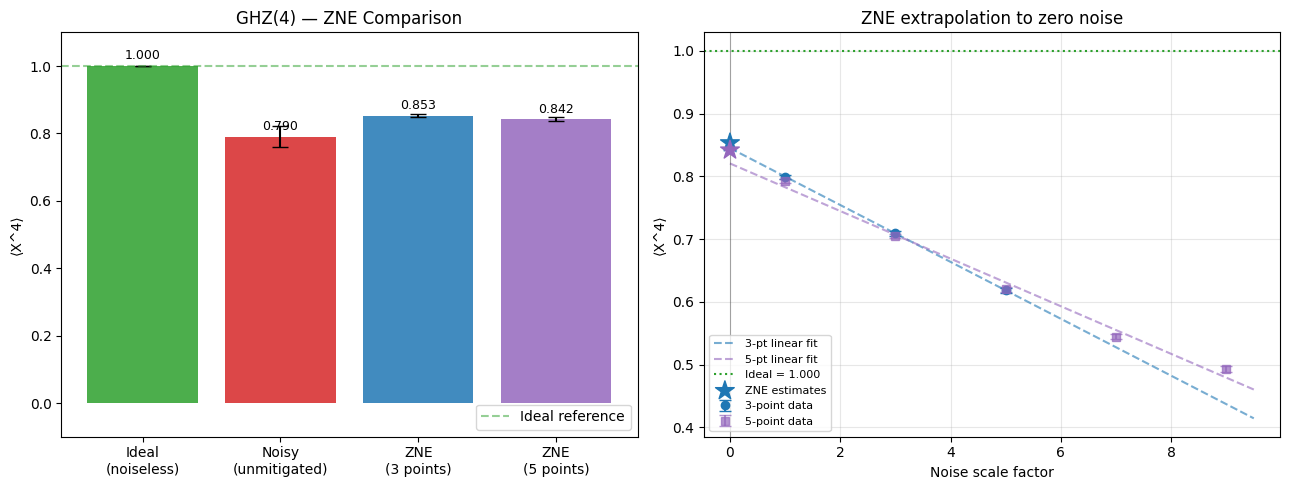

In [23]:
fig, (ax_bar, ax_fit) = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: bar chart of the four values ---
labels = ["Ideal\n(noiseless)", "Noisy\n(unmitigated)", "ZNE\n(3 points)", "ZNE\n(5 points)"]
values = [ideal_ev, noisy_ev, zne_ev_3pt, zne_ev_5pt]
errors = [0.0, noisy_std, zne_std_3pt, zne_std_5pt]
colors = ["#2ca02c", "#d62728", "#1f77b4", "#9467bd"]

bars = ax_bar.bar(labels, values, yerr=errors, color=colors, capsize=6, alpha=0.85)
ax_bar.axhline(ideal_ev, color="#2ca02c", linestyle="--", alpha=0.5, label="Ideal reference")
ax_bar.set_ylabel(f"⟨X^{N_QUBITS}⟩")
ax_bar.set_title(f"GHZ({N_QUBITS}) — ZNE Comparison")
ax_bar.legend(loc="lower right")
ax_bar.set_ylim(min(values + [0]) - 0.1, max(values + [1.05]) + 0.05)
for bar, v in zip(bars, values):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                f"{v:.3f}", ha="center", fontsize=9)

# --- Right: extrapolation curves ---
factors_3 = np.array([1, 3, 5])
factors_5 = np.array([1, 3, 5, 7, 9])
ax_fit.errorbar(factors_3, raw_evs_3pt.flatten(),
                yerr=zne_result_3pt[0].metadata["zne"]["noisy_stds"].flatten(),
                fmt="o", color="#1f77b4", label="3-point data", capsize=4)
ax_fit.errorbar(factors_5, raw_evs_5pt.flatten(),
                yerr=zne_result_5pt[0].metadata["zne"]["noisy_stds"].flatten(),
                fmt="s", color="#9467bd", label="5-point data", capsize=4, alpha=0.7)

# Plot the linear fits extending to x=0.
xx = np.linspace(0, max(factors_5) + 0.5, 50)
fit3 = np.polyfit(factors_3, raw_evs_3pt.flatten(), 1)
fit5 = np.polyfit(factors_5, raw_evs_5pt.flatten(), 1)
ax_fit.plot(xx, np.polyval(fit3, xx), "--", color="#1f77b4", alpha=0.6, label="3-pt linear fit")
ax_fit.plot(xx, np.polyval(fit5, xx), "--", color="#9467bd", alpha=0.6, label="5-pt linear fit")

ax_fit.axhline(ideal_ev, color="#2ca02c", linestyle=":", label=f"Ideal = {ideal_ev:.3f}")
ax_fit.axvline(0, color="black", alpha=0.3, linewidth=0.8)
ax_fit.scatter([0, 0], [zne_ev_3pt, zne_ev_5pt],
               marker="*", s=200, color=["#1f77b4", "#9467bd"],
               zorder=5, label="ZNE estimates")
ax_fit.set_xlabel("Noise scale factor")
ax_fit.set_ylabel(f"⟨X^{N_QUBITS}⟩")
ax_fit.set_title("ZNE extrapolation to zero noise")
ax_fit.legend(loc="lower left", fontsize=8)
ax_fit.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Summary Table

In [24]:
print(f"{'Method':<25} {'Value':>10} {'Error vs ideal':>18}")
print("-" * 56)
print(f"{'Ideal (noiseless)':<25} {ideal_ev:>+10.6f} {0.0:>18.6f}")
print(f"{'Noisy (unmitigated)':<25} {noisy_ev:>+10.6f} {abs(noisy_ev - ideal_ev):>18.6f}")
print(f"{'ZNE 3-point (1,3,5)':<25} {zne_ev_3pt:>+10.6f} {abs(zne_ev_3pt - ideal_ev):>18.6f}")
print(f"{'ZNE 5-point (1,3,5,7,9)':<25} {zne_ev_5pt:>+10.6f} {abs(zne_ev_5pt - ideal_ev):>18.6f}")

improvement_3 = (abs(noisy_ev - ideal_ev) - abs(zne_ev_3pt - ideal_ev)) / abs(noisy_ev - ideal_ev) * 100
improvement_5 = (abs(noisy_ev - ideal_ev) - abs(zne_ev_5pt - ideal_ev)) / abs(noisy_ev - ideal_ev) * 100
print(f"\nZNE 3-point reduced error by {improvement_3:+.1f}%")
print(f"ZNE 5-point reduced error by {improvement_5:+.1f}%")

Method                         Value     Error vs ideal
--------------------------------------------------------
Ideal (noiseless)          +1.000000           0.000000
Noisy (unmitigated)        +0.790000           0.210000
ZNE 3-point (1,3,5)        +0.853176           0.146824
ZNE 5-point (1,3,5,7,9)    +0.841699           0.158301

ZNE 3-point reduced error by +30.1%
ZNE 5-point reduced error by +24.6%
